# Seismic Modeling

In [ ]:
from geod67lib.wavefield import *
from geod67lib.wavefield.damp import generate_damp_mask

from geod67lib import fd

import numpy as np

import matplotlib.pyplot as plt

2026-05-31 15:49:50.664068: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-31 15:49:50.666057: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-31 15:49:50.958806: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-31 15:49:57.603991: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

In [ ]:
shape = (301, 301)
h = (10, 10)

nbl = 50

vp_data = 1.5 * np.ones(shape, dtype=np.float32)
vp_data[:,shape[1]//2:] = 3

np.pad(vp_data, nbl, mode='edge')
damp_mask = generate_damp_mask(vp_data, nbl)

vp = VelocityModel(vp_data, h[0], h[1])

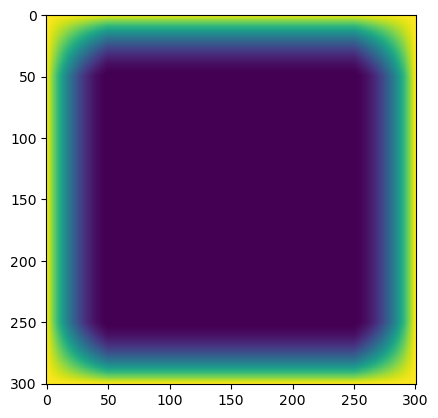

In [ ]:
plt.imshow(damp_mask)

In [ ]:
src_positions = np.array([[shape[0]//2, nbl]], dtype=np.int32)
rec_positions = np.array([[shape[0]//3, shape[1]//3 + nbl]], dtype=np.int32)

In [ ]:
dt = 1.5  # ms
tn = 2000 # ms
fpeak = 5 * 1e-3

src_wavelet = np.array([ricker(fpeak, dt, int(tn//dt))])

In [ ]:
ap = AquisitionParameters(src_positions, rec_positions, dt, tn, src_wavelet)

In [ ]:
op = ForwardOperator(ap, damp_mask)

In [ ]:
u_history = op.forward(vp, True)

0 / 1333
1 / 1333
2 / 1333
3 / 1333
4 / 1333
5 / 1333
6 / 1333
7 / 1333
8 / 1333
9 / 1333
10 / 1333
11 / 1333
12 / 1333
13 / 1333
14 / 1333
15 / 1333
16 / 1333
17 / 1333


18 / 1333
19 / 1333
20 / 1333
21 / 1333
22 / 1333
23 / 1333
24 / 1333
25 / 1333
26 / 1333
27 / 1333
28 / 1333
29 / 1333
30 / 1333
31 / 1333
32 / 1333
33 / 1333
34 / 1333
35 / 1333
36 / 1333
37 / 1333
38 / 1333
39 / 1333
40 / 1333
41 / 1333
42 / 1333
43 / 1333
44 / 1333
45 / 1333
46 / 1333
47 / 1333
48 / 1333
49 / 1333
50 / 1333
51 / 1333
52 / 1333
53 / 1333
54 / 1333
55 / 1333
56 / 1333
57 / 1333
58 / 1333
59 / 1333
60 / 1333
61 / 1333
62 / 1333
63 / 1333
64 / 1333
65 / 1333
66 / 1333
67 / 1333
68 / 1333
69 / 1333
70 / 1333
71 / 1333
72 / 1333
73 / 1333
74 / 1333
75 / 1333
76 / 1333
77 / 1333
78 / 1333
79 / 1333
80 / 1333
81 / 1333
82 / 1333
83 / 1333
84 / 1333
85 / 1333
86 / 1333
87 / 1333
88 / 1333
89 / 1333
90 / 1333
91 / 1333
92 / 1333
93 / 1333
94 / 1333
95 / 1333
96 / 1333
97 / 1333
98 / 1333
99 / 1333
100 / 1333
101 / 1333
102 / 1333
103 / 1333
104 / 1333
105 / 1333
106 / 1333
107 / 1333
108 / 1333
109 / 1333
110 / 1333
111 / 1333
112 / 1333
113 / 1333
114 / 1333
115 / 1333
116 

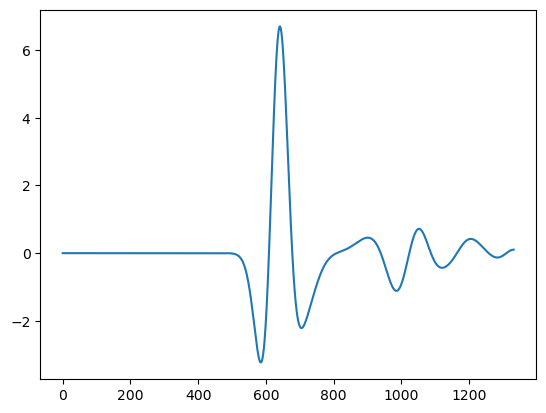

In [ ]:
plt.plot(ap.rec_data[0])

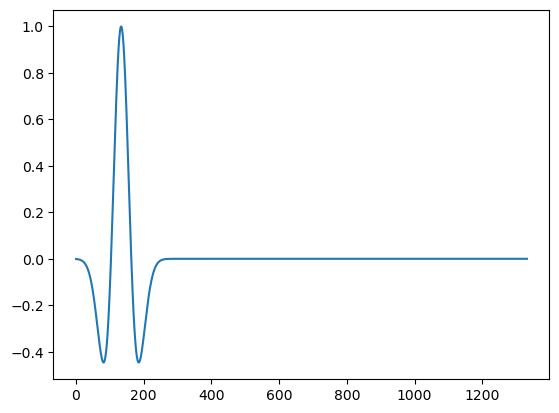

In [ ]:
plt.plot(ricker(fpeak, dt, tn//dt))

In [ ]:
ap.nt

1333

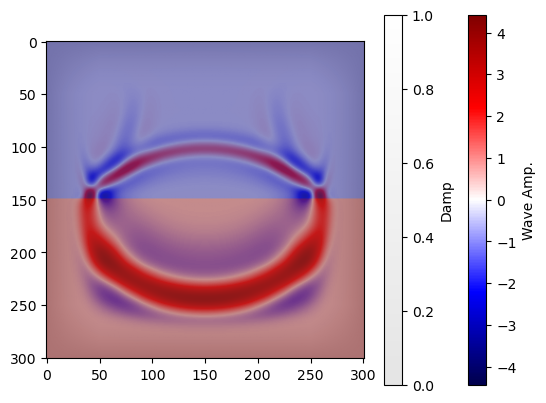

In [ ]:
idx = 800
vmax = np.abs(u_history[idx]).max()
plt.imshow(u_history[idx].T - np.median(u_history[idx]), cmap='seismic', vmax=vmax , vmin=-vmax)
# plt.imshow(u_history[idx].T - u_history[idx-1].T, cmap='seismic', vmax=vmax , vmin=-vmax)
plt.colorbar(label='Wave Amp.')
plt.imshow(vp.data.T, cmap='jet', alpha=0.5, vmin = vp.data.min(), vmax=vp.data.max())
plt.imshow(1-damp_mask.T, cmap='grey', alpha=0.1)
# plt.colorbar(label='$v_P$ (km/s)')
plt.colorbar(label='Damp')

array([[ 1,  2,  3,  4,  5],
       [ 2,  4,  6,  8, 10],
       [ 3,  6,  9, 12, 15],
       [ 4,  8, 12, 16, 20],
       [ 5, 10, 15, 20, 25]])

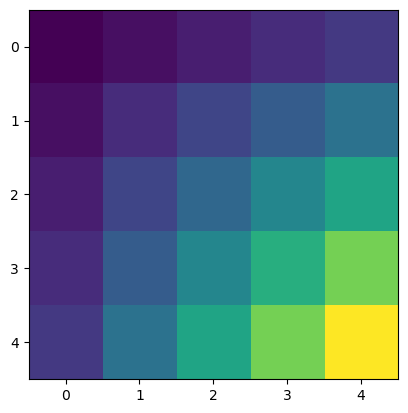

In [ ]:
A = np.array([ (np.arange(5) + 1) * (i + 1) for i in range(5) ])
plt.imshow(A)
A

In [ ]:
A[-1, :]

array([ 5, 10, 15, 20, 25])

In [ ]:
fd.shift2d(A, 1, 0)

array([[ 2,  4,  6,  8, 10],
       [ 3,  6,  9, 12, 15],
       [ 4,  8, 12, 16, 20],
       [ 5, 10, 15, 20, 25],
       [ 5, 10, 15, 20, 25]])